In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\dhruv\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Dataset
data = pd.read_csv("../data/creditcard.csv")

alerts = pd.read_csv("../data/high_risk_alerts.csv")

print("Full dataset shape:", data.shape)
print("Alerts shape:", alerts.shape)

alerts.head()

Full dataset shape: (284807, 31)
Alerts shape: (318, 36)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V26,V27,V28,Amount,Class,fraud_probability,anomaly_score,anomaly_risk,amount_risk,risk_score
0,7526.0,0.008430,4.137837,-6.240697,6.675732,0.768307,-3.353060,-1.631735,0.154612,-2.795892,...,0.507963,0.735822,0.513574,1.0,1,0.960,0.042599,0.601466,0.000039,66.044747
1,7535.0,0.026779,4.132464,-6.560600,6.348557,1.329666,-2.513479,-1.689102,0.303253,-3.139409,...,0.540675,0.737040,0.496699,1.0,1,0.980,0.038697,0.610609,0.000039,67.319052
2,7543.0,0.329594,3.712889,-5.775935,6.078266,1.667359,-2.420168,-0.812891,0.133080,-2.214311,...,0.555265,0.530507,0.404474,1.0,1,0.970,0.075019,0.525499,0.000039,64.265747
3,7551.0,0.316459,3.809076,-5.615159,6.047445,1.554026,-2.651353,-0.746579,0.055586,-2.678679,...,0.491192,0.518868,0.402528,1.0,1,0.965,0.073269,0.529599,0.000039,64.138745
4,7610.0,0.725646,2.300894,-5.329976,4.007683,-1.730411,-1.732193,-3.968593,1.063728,-0.486097,...,0.351909,0.594550,0.099372,1.0,1,0.965,0.062656,0.554467,0.000039,64.884800


In [3]:
# Load Model
fraud_model = joblib.load("../models/fraud_detection_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [4]:
# Get original features used during model training
model_features = fraud_model.feature_names_in_

print("Model features:")
print(model_features)

Model features:
['Time' 'V1' 'V2' 'V3' 'V4' 'V5' 'V6' 'V7' 'V8' 'V9' 'V10' 'V11' 'V12'
 'V13' 'V14' 'V15' 'V16' 'V17' 'V18' 'V19' 'V20' 'V21' 'V22' 'V23' 'V24'
 'V25' 'V26' 'V27' 'V28' 'Amount']


In [5]:
X_alerts = alerts[model_features]

print("Feature matrix shape:", X_alerts.shape)

Feature matrix shape: (318, 30)


In [6]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(fraud_model)

shap_values = explainer.shap_values(X_alerts)

print("SHAP values computed")

SHAP values computed


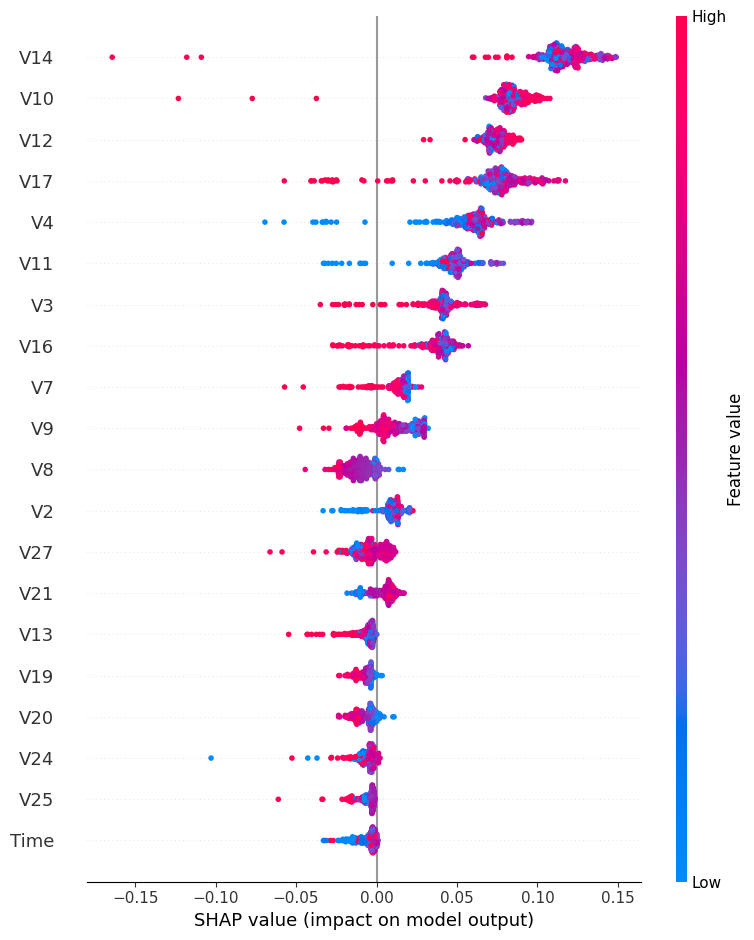

In [7]:
# Global Feature Importance
if isinstance(shap_values, list):
    shap_vals = shap_values[1]   # fraud class
else:
    shap_vals = shap_values[:, :, 1]  # fraud class from 3D array

# Global importance plot
shap.summary_plot(shap_vals, X_alerts)

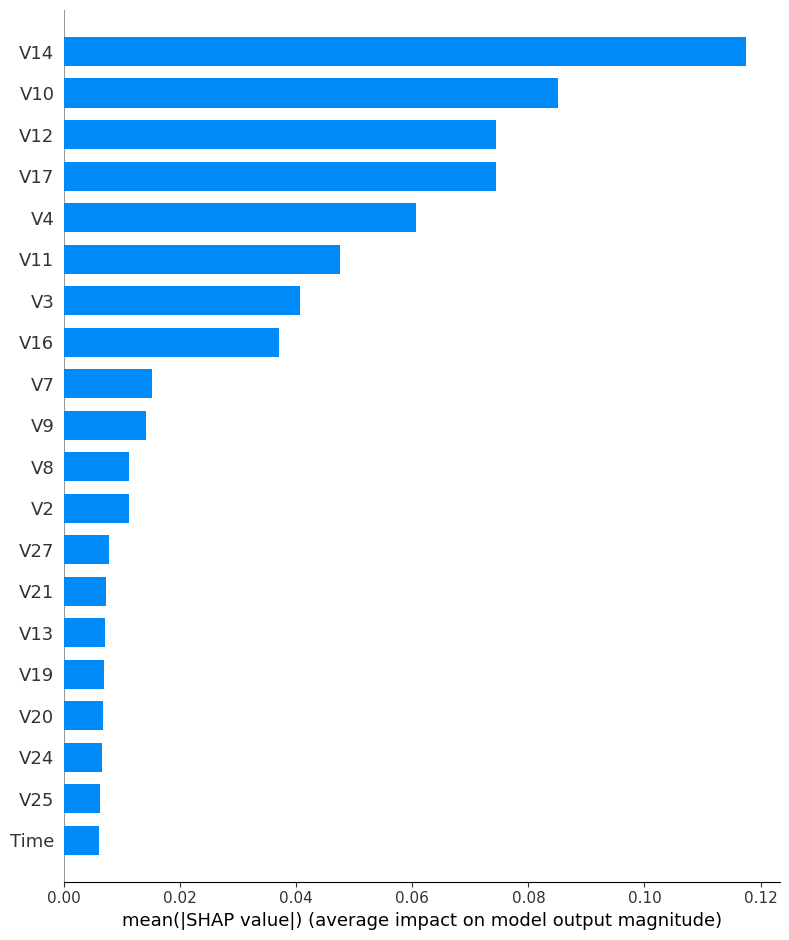

In [8]:
shap.summary_plot(
    shap_vals,
    X_alerts,
    plot_type="bar"
)

### Key Insights

The SHAP analysis highlights the most influential features contributing to fraud predictions.

The model relies primarily on PCA components V14, V10, V12, and V17 to identify suspicious transaction patterns.

Higher values of these components significantly increase the probability of a transaction being classified as fraudulent.

Because the dataset uses PCA-transformed variables, these components represent latent behavioral patterns derived from the original financial transaction attributes.

Explainability analysis allows investigators to understand why specific transactions were flagged, improving transparency and trust in the fraud detection system.